# Summary statistics for the dataset

This notebook produces the baseline statistics and initial descriptive graphs for the dataset (without any topic or sentiment analysis). 

In [1]:
import pandas as pd
import numpy as np
import math 

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd

from elasticsearch import Elasticsearch

from database.comments import Comments

import sys
sys.path.append('../functions')
import preprocessing_fncs as ppf
from elastic_search_fncs import ElasticSearchFncs

### Dataset 1 - geospatial boundaries 

In [2]:
# local authority districts
london_lad = gpd.read_file('../data/london_geos/Local_Authority_Districts_May_2024_London.geojson')
# local planning districts
london_lpa = gpd.read_file('../data/london_geos/local-planning-authority-london.geojson')

# label london_lad wit outer or inner london
inner_london = ['Camden', 'Greenwich', 'Hackney', 'Hammersmith and Fulham', 'Islington', 'Kensington and Chelsea', 
                'Lambeth', 'Lewisham', 'Southwark', 'Tower Hamlets', 'Wandsworth', 'Westminster', 'City of London', 'Newham']
london_lad['london_area'] = london_lad['LAD24NM'].apply(lambda x: 'Inner London' if x in inner_london else 'Outer London')

# create seperate dataframe with the LPAs independent of the LADs
additional_lpas = london_lpa[london_lpa['new_lpa_names'].isin(['LLDC', 'OPDC'])]
additional_lpas = additional_lpas.copy()
additional_lpas['centroid_x'] = additional_lpas.geometry.centroid.x
additional_lpas['centroid_y'] = additional_lpas.geometry.centroid.y

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_25377/1966295847.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  additional_lpas['centroid_x'] = additional_lpas.geometry.centroid.x
/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_25377/1966295847.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  additional_lpas['centroid_y'] = additional_lpas.geometry.centroid.y


### Dataset 2 - planning applications

This is the .csv file extracted from the [Planning London Datahub](https://www.london.gov.uk/programmes-strategies/planning/digital-planning/planning-london-datahub) (PLD) which was used to identify applications for web-scraping. 

In [3]:
# Application dataset 
application_df_path = "/Users/bea/Documents/AI4CI/projects/comment_summariser/comment_summariser/data/PLD_application_ids/all_since21_cleaned.csv"
application_df = pd.read_csv(application_df_path)
print(f"There are {len(application_df)} applications in the dataset.")

# drop 'Bromley' applications -  since I haven't been able to get the comments for these
application_df = application_df[application_df['borough'] != 'Bromley']
print(f"There are {len(application_df)} applications in the dataset after dropping Bromley applications.")

# format borough names
application_df = ppf.format_df(application_df, 'borough')

There are 5850 applications in the dataset.
There are 5077 applications in the dataset after dropping Bromley applications.


In [4]:
included_lads = list(application_df['borough'].unique())

Now ping the elastic search database - which gives a more complete list of the applications

In [5]:
esf = ElasticSearchFncs()
esf.check_connection()

pld_df = esf.res_units_x_query(min_res_units=1, since_year="01/01/2021", to_year="01/05/2025")

/Users/bea/Documents/AI4CI/projects/comment_summariser/neighour_nlp/notebooks/../functions/elastic_search_fncs.py:29: ElasticsearchWarning: The role [reporting_user] is deprecated and will be removed in a future version of Elasticsearch. Please use Kibana feature privileges instead
  if self.es.ping():


Connected to Elastic Search


/Users/bea/Documents/AI4CI/projects/comment_summariser/neighour_nlp/notebooks/../functions/elastic_search_fncs.py:38: ElasticsearchWarning: The role [reporting_user] is deprecated and will be removed in a future version of Elasticsearch. Please use Kibana feature privileges instead
  response = self.es.search(index=self.index, body=query, scroll="2m", size=10000)
/Users/bea/Documents/AI4CI/projects/comment_summariser/neighour_nlp/notebooks/../functions/elastic_search_fncs.py:47: ElasticsearchWarning: The role [reporting_user] is deprecated and will be removed in a future version of Elasticsearch. Please use Kibana feature privileges instead
  response = self.es.scroll(scroll_id=scroll_id, scroll="2m")


In [6]:
pld_df = ppf.format_df(pld_df)

# this function adds a 'housing_type' column to the pld_df - which summarises the housing type based on the number of units of each type
pld_df = ppf.add_housing_type(pld_df)

# merge housing type into application_df
application_df = pd.merge(application_df, pld_df[['lpa_app_no', 'housing_type']], left_on='lpa_app_no', right_on='lpa_app_no', how='left')

### Dataset 3 - web-scraped community comments 

This is the remote database of comments resulting from web-scraping. Note: this dataset matches to the planning applications on the column 'application_id'. 

In [7]:
# Comments dataset
cs = Comments()
comment_df = cs.read_all().copy()

# format borough names
comment_df = ppf.format_borough(comment_df, 'council')

comment_df.head()

Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score
0,69996,Lambeth,22/01569/FUL_13,22/01569/FUL,None,Objects,2022-06-27,I am strongly opposed to this planning applica...,2025-04-04,NaN,NaN,I am strongly opposed to this planning applica...,None,-0.169995
1,69999,Lambeth,22/01569/FUL_16,22/01569/FUL,None,Objects,2022-06-27,I strongly object to this planning application...,2025-04-04,NaN,NaN,I strongly object to this planning application...,None,-0.474422
2,70001,Lambeth,22/01569/FUL_18,22/01569/FUL,None,Objects,2022-06-27,I have read all the documents as a close neigh...,2025-04-04,NaN,NaN,I have read all the documents as a close neigh...,None,-0.352204
3,70008,Lambeth,22/01569/FUL_25,22/01569/FUL,None,Objects,2022-06-27,I am very concerned what this development woul...,2025-04-04,NaN,NaN,I am very concerned what this development woul...,None,-0.605155
4,70009,Lambeth,22/01569/FUL_26,22/01569/FUL,None,Objects,2022-06-27,Worry for children's safety as this build will...,2025-04-04,NaN,NaN,Worry for children's safety as this build will...,None,-0.482568


In [8]:
# update application_df by adding comment counts

app_count = comment_df.groupby('application_id')['id'].count().reset_index()
app_count.columns = ['application_id', 'comment_count']

application_df = application_df.merge(app_count, left_on='lpa_app_no', right_on='application_id', how='left')
application_df['comment_count'] = application_df['comment_count'].fillna(0).astype(int)
application_df.drop(columns=['application_id'], inplace=True)

application_df = ppf.format_df(application_df)
application_df = ppf.create_decision_outcomes(application_df, completion_date_col_name='decision_date')

In [9]:
print(f"The councils in the dataset are: {comment_df['council'].unique()}")
print(f"Total number of comments: {len(comment_df)}")
print(f"Total number of applications (with at least one comment scraped): {len(comment_df.application_id.unique())}")

The councils in the dataset are: ['Lambeth' 'Barnet' 'Ealing' 'Westminster' 'Newham' 'Brent' 'Southwark'
 'City of London']
Total number of comments: 30393
Total number of applications (with at least one comment scraped): 2453


In [10]:
comment_df.groupby("application_id").size().describe()

count    2453.000000
mean       12.390135
std        42.732741
min         1.000000
25%         1.000000
50%         3.000000
75%         8.000000
max       844.000000
dtype: float64

In [11]:
# Application-level stats per council
application_stats = (
    application_df
    .groupby('borough')
    .agg(
        total_applications=('lpa_app_no', 'count'),
        total_proposed_residential_units=('total_no_proposed_residential_units', 'sum'),
        total_comments=('comment_count', 'sum'),
        mean_comments_per_application=('comment_count', 'mean')
    )
    .reset_index()
    .rename(columns={'borough': 'council'})
)

# Comment-level stats per council
comment_stats = (
    comment_df
    .groupby('council')
    .agg(
        no_applications_with_comments=('application_id', 'nunique'),
        total_comment_count=('comment_id', 'nunique')
    )
    .reset_index()
)

# Final consolidated table
unique_app_counts = (
    application_stats
    .merge(comment_stats, on='council', how='left')
    .sort_values('total_applications')
)

unique_app_counts

,council,total_applications,total_proposed_residential_units,total_comments,mean_comments_per_application,no_applications_with_comments,total_comment_count
2,City of London,21,3899,38,1.809524,14,38
6,Southwark,308,7054,2396,7.779221,152,2488
5,Newham,497,11264,922,1.855131,158,750
7,Westminster,497,6102,1342,2.700201,238,1347
4,Lambeth,546,3347,2834,5.190476,208,2587
1,Brent,935,12509,2291,2.450267,395,2419
3,Ealing,1123,12182,11314,10.074800,497,11592
0,Barnet,1308,10128,9262,7.081040,791,9172


In [12]:
# get total number of applications, total number of [ropsed residential units, sum of comments count and mean comments for all of application_df
overall_summary = {
    'total_applications': application_df['lpa_app_no'].nunique(),
    'total_proposed_residential_units': application_df['total_no_proposed_residential_units'].sum(),
    'total_comments': application_df['comment_count'].sum(),
    'mean_comments_per_application': application_df['comment_count'].mean()
}
overall_summary

{'total_applications': 5071,
 'total_proposed_residential_units': 66485,
 'total_comments': 30399,
 'mean_comments_per_application': 5.8068767908309455}

In [13]:
application_df.groupby('housing_type')['total_no_proposed_residential_units'].agg(['mean', 'max', 'count', 'sum'])

,mean,max,count,sum
housing_type,,,,
Market housing,6.101031,1312,4365,26631
Mixed affordable housing,69.817073,1158,246,17175
Mixed social housing,243.916667,1610,48,11708
Other,13.160000,772,75,987
Self-build housing,1.517361,8,288,437
Social housing,8.707865,102,89,775


### Local authority plot 

Map of the local authority districts included in the dataset. 

In [14]:
# # format comment_df lat and lon to london_lad crs
# # assuming original are (EPSG:27700)
# comment_gdf = gpd.GeoDataFrame(
#     comment_df,
#     geometry=gpd.points_from_xy(comment_df.lon, comment_df.lat),
#     crs="EPSG:4326"
# )

# comment_gdf = comment_gdf.to_crs(london_lad.crs)

In [15]:
# function for assigning location of the text label when plotting 
def assign_side(row, minx, maxx, miny, maxy):
    x, y = row['centroid_x'], row['centroid_y']
    # Calculate distances to each edge
    dist_left = abs(x - minx)
    dist_right = abs(maxx - x)
    dist_bottom = abs(y - miny)
    dist_top = abs(maxy - y)

    # Assign side by minimum distance to bounding box edge
    distances = {'left': dist_left, 'right': dist_right, 'top': dist_top, 'bottom': dist_bottom}
    assigned_side = min(distances, key=distances.get)
    return assigned_side

In [16]:
# Bounding box
minx, miny, maxx, maxy = london_lad.total_bounds
x_margin = (maxx - minx) * 0.05
y_margin = (maxy - miny) * 0.05

highlighted = london_lad[london_lad['LAD24NM'].isin(included_lads)].copy()
highlighted['centroid'] = highlighted.geometry.centroid

# Sort based on y or x using `.apply()` to extract coords
highlighted['centroid_x'] = highlighted['centroid'].apply(lambda point: point.x)
highlighted['centroid_y'] = highlighted['centroid'].apply(lambda point: point.y)

highlighted['side'] = highlighted.apply(assign_side, axis=1, args=(minx, maxx, miny, maxy))

/var/folders/4n/x6w1yfcx01qbymrsfpz4ybq00000gn/T/ipykernel_25377/868198591.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  highlighted['centroid'] = highlighted.geometry.centroid


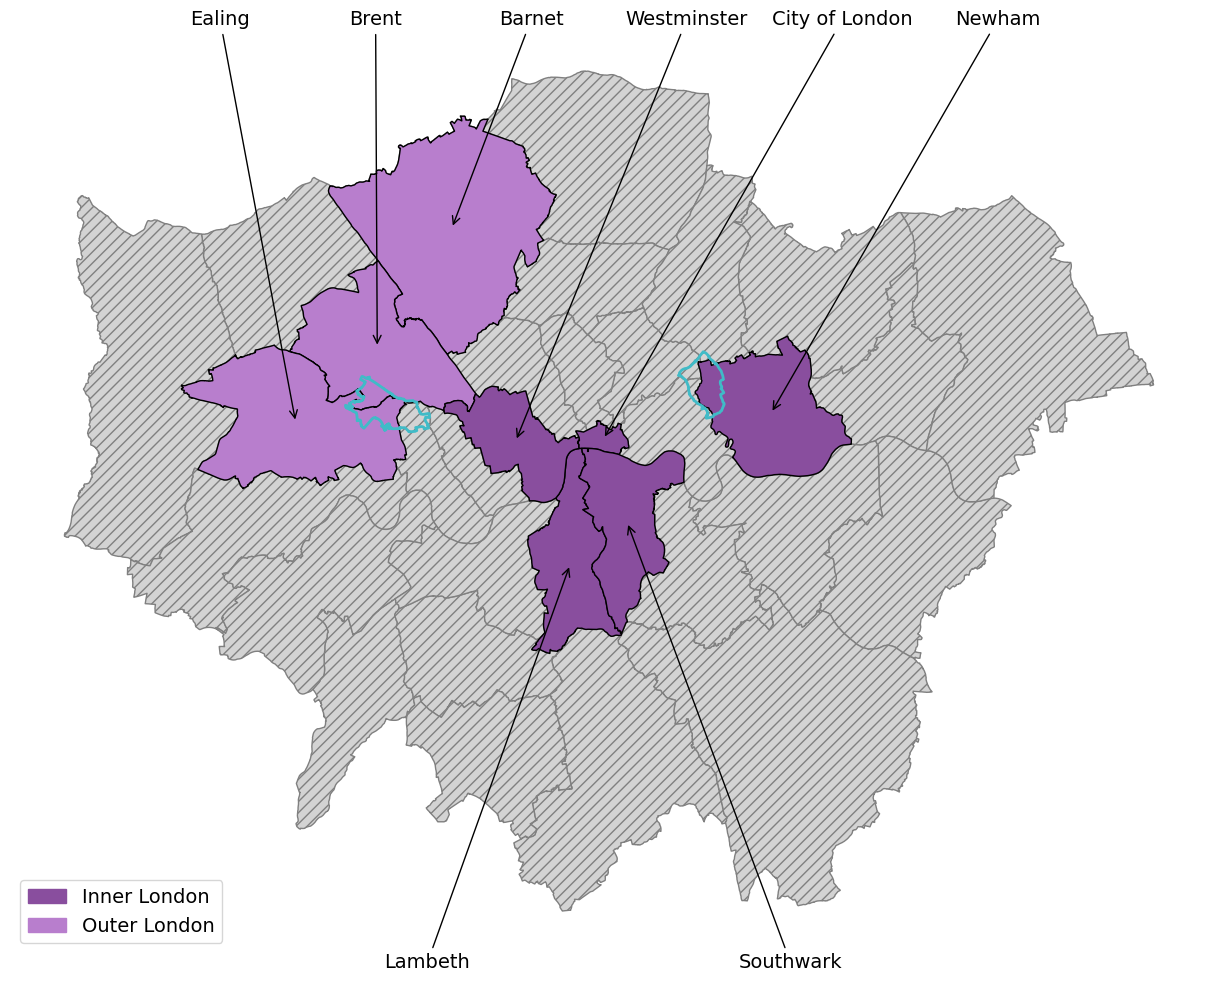

In [17]:
# Create a new column to indicate if the council is in the councils array
london_lad['highlight'] = london_lad['LAD24NM'].apply(lambda x: x in included_lads)

# colour map by inner and outer london
cmap = {'Inner London': "#894e9e", 'Outer London': "#b87ecd"}
london_lad['colour'] = london_lad['london_area'].map(cmap)

# Plot the GeoDataFrame
fig, ax = plt.subplots(1, 1, figsize=(16, 12))
london_lad.plot(ax=ax, color='lightgrey', edgecolor='grey', hatch="///")  # Default color for all areas

# plot highlighted coouncils (colour coded by inner and outer london)
subset = london_lad[london_lad['highlight']]

subset.plot(
    ax=ax,
    color=subset['colour'],
    edgecolor='black'
)

# add legend for inner and outer london
inner_patch = mpatches.Patch(color="#894e9e", label='Inner London')
outer_patch = mpatches.Patch(color="#b87ecd", label='Outer London')
plt.legend(handles=[inner_patch, outer_patch], loc='lower left', fontsize=14)

# # add scatter of comments - comment out to get map without scatter 
# ax.scatter(
#     comment_gdf['lon'],
#     comment_gdf['lat'],
#     s=10,
#     color="#a0e8ef",
#     alpha=0.2,
#     label='Comments'
# )  

# plot additional lpas boundaries
additional_lpas.boundary.plot(ax=ax, color="#40bbc7", linewidth=2, linestyle='---')

# # add labels for additional lpds with arrow pointing to centroid
# def annotate_additional_lpds(df):
#     for _, row in df.iterrows():
#         ax.annotate(
#             row['new_lpa_names'],
#             xy=row['geometry'].centroid.coords[0],
#             ha='center',
#             fontsize=6,
#             color='#40bbc7',
#             arrowprops=dict(arrowstyle='->', color='#40bbc7')
#         )

# annotate_additional_lpds(additional_lpds)

def annotate_side(df, side):
    # Sort the df by coordinate axis to get label order
    if side in ['left', 'right']:
       df = df.sort_values(by='centroid_y')  # south → north
    else:  # 'top' or 'bottom'
        df = df.sort_values(by='centroid_x')  # west → east
    
    n = len(df)
    if side in ['left', 'right']:
        # evenly space labels vertically
        y_positions = np.linspace(miny, maxy, n + 2)[1:-1]
        for i, (idx, row) in enumerate(df.iterrows()):
            cx, cy = row['centroid_x'], row['centroid_y']
            if side == 'left':
                lx, ly = minx - x_margin, y_positions[i]
                ha, va = 'right', 'center'
            else:  # right
                lx, ly = maxx + x_margin, y_positions[i]
                ha, va = 'left', 'center'

            ax.annotate(
                row['LAD24NM'],
                xy=(cx, cy),
                xytext=(lx, ly),
                textcoords='data',
                arrowprops=dict(arrowstyle='->', color='black', lw=1),
                fontsize=14,
                ha=ha,
                va=va,
                color='black'
            )
    else:
        # evenly space labels horizontally
        x_positions = np.linspace(minx, maxx, n + 2)[1:-1]
        for i, (idx, row) in enumerate(df.iterrows()):
            cx, cy = row['centroid_x'], row['centroid_y']
            if side == 'top':
                lx, ly = x_positions[i], maxy + y_margin
                ha, va = 'center', 'bottom'
            else:  # bottom
                lx, ly = x_positions[i], miny - y_margin
                ha, va = 'center', 'top'

            ax.annotate(
                row['LAD24NM'],
                xy=(cx, cy),
                xytext=(lx, ly),
                textcoords='data',
                arrowprops=dict(arrowstyle='->', color='black', lw=1),
                fontsize=14,
                ha=ha,
                va=va,
                color='black'
            )

for side, group in highlighted.groupby('side'):
    annotate_side(group, side)

ax.set_axis_off()

plt.savefig("../results/figures/just_london_councils_highlighted.png", dpi=1000)
plt.show()

### Local authority barchart 
Plot stacked vertical bar chart showing the number of applications and the proportion receiving comments. 

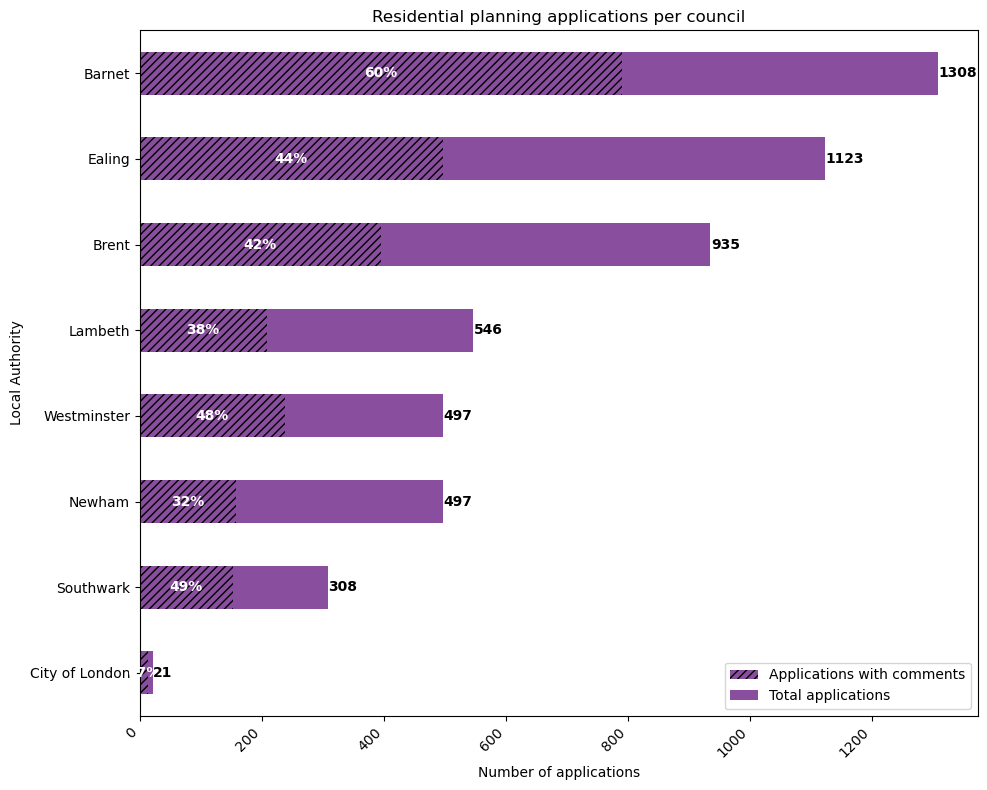

In [18]:
# make a copy to avoid modifying original
df = unique_app_counts.copy()

# compute the remainder (total minus subset). Clip to 0 to avoid negatives if data odd.
df['no_applications_remaining'] = (df['total_applications'] - df['no_applications_with_comments']).clip(lower=0)

# plot stacked bars: first the subset, then the remainder so subset is at the left of the bar
ax = df.plot.barh(
    x='council',
    y=['no_applications_with_comments', 'no_applications_remaining'],
    stacked=True,
    figsize=(10, 8),
    title='Residential planning applications per council',
    ylabel='Local Authority',
    xlabel='Number of applications',
    color=["#894e9e", "#894e9e"]  # same base color; we'll hatch the first
)

# patch list and counts
bars = ax.patches
n = len(df)

# apply hatching to the "with comments" bars (first n patches)
for i in range(n):
    bars[i].set_hatch('////')

# annotate
for i in range(n):
    bar_comments = bars[i]
    bar_remainder = bars[i + n]

    comments_w = bar_comments.get_width()
    remainder_w = bar_remainder.get_width()
    total_w = comments_w + remainder_w

    y = bar_comments.get_y() + bar_comments.get_height() / 2

    # --- 1) Hashed section percentage label (white) ---
    if total_w > 0:
        pct = comments_w / total_w * 100
        label = f'{pct:.0f}%'  # round to nearest whole %
    else:
        label = ''

    ax.text(
        bar_comments.get_x() + comments_w / 2,
        y,
        label,
        va='center',
        ha='center',
        fontsize=10,
        color='white',
        fontweight='bold'
    )

    # --- 2) Total label to the right ---
    ax.text(
        bar_remainder.get_x() + remainder_w + 1,
        y,
        f'{int(total_w)}',
        va='center',
        ha='left',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

# show legend for the hatched (with comments) section and the total
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend([handles[0], handles[1]], ['Applications with comments', 'Total applications'], loc='lower right')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("../results/figures/bar_applications_per_council.png", dpi=500)
plt.show()


### Histogram of number of comments per planning application 

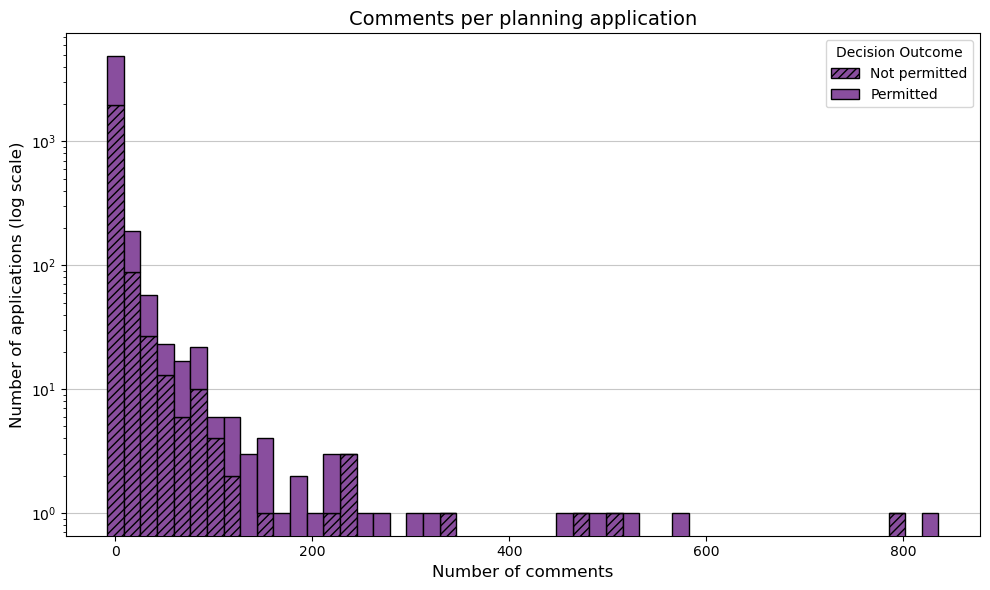

In [19]:
plt.figure(figsize=(10, 6))

counts, bins, patches = plt.hist(
    [
        application_df.loc[application_df['outcome'] != 'Permitted', 'comment_count'],
        application_df.loc[application_df['outcome'] == 'Permitted', 'comment_count']
    ],
    bins=50,
    stacked=True,
    color=["#894e9e", "#894e9e"],
    edgecolor="black",
    align="left",
    zorder=3,
    label=["Not permitted", "Permitted"]
)

# Hatch the permitted bars (second dataset)
for p in patches[0]:
    p.set_hatch("////")

plt.yscale("log")
plt.title("Comments per planning application", fontsize=14)
plt.xlabel("Number of comments", fontsize=12)
plt.ylabel("Number of applications (log scale)", fontsize=12)
plt.grid(axis="y", alpha=0.7, zorder=0)
plt.legend(title="Decision Outcome")
plt.tight_layout()

plt.savefig(
    "../results/figures/hist_comments_per_application_permitted.png",
    dpi=500
)
plt.show()

### Applications and comments by residential build type 

<Figure size 1200x1000 with 0 Axes>

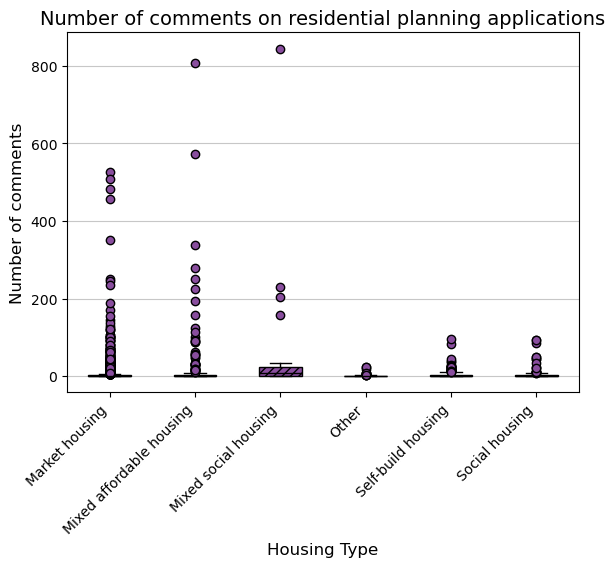

In [20]:
# box plot of comments per application by housing type
plt.figure(figsize=(12,10))

bp = application_df.boxplot(
    column='comment_count',
    by='housing_type',
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor="#894e9e", color='black', hatch='////'),
    medianprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(markerfacecolor="#894e9e", markeredgecolor='black'),
    zorder=3
)   

plt.title('Number of comments on residential planning applications', fontsize=14)
plt.suptitle('')  # Remove the automatic 'Boxplot grouped by ...' title
plt.xticks(rotation=45, ha='right')
plt.xlabel('Housing Type', fontsize=12)
plt.ylabel('Number of comments', fontsize=12)
plt.grid(axis='y', alpha=0.7, zorder=0)

plt.savefig("../results/figures/boxplot_comments_per_application_housing_type.png", dpi=500)
plt.show()

<Figure size 1200x1000 with 0 Axes>

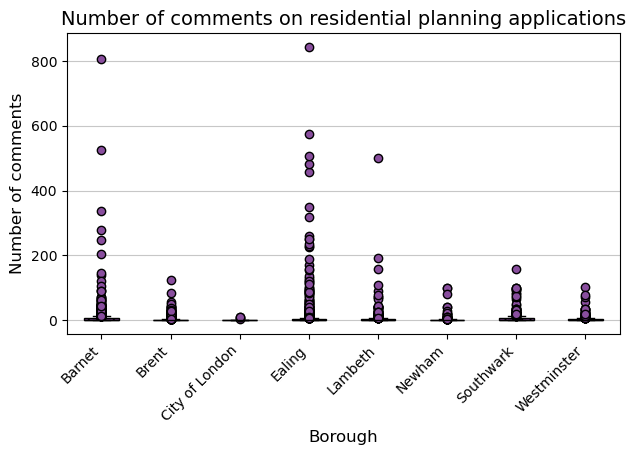

In [21]:
# box plot of comments per application by borough
plt.figure(figsize=(12,10))
color = "#894e9e"
bp = application_df.boxplot(
    column='comment_count',
    by='borough',
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor=color, color='black', hatch='////'),
    medianprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(markerfacecolor=color, markeredgecolor='black'),
    zorder=3
)
plt.title('Number of comments on residential planning applications', fontsize=14)
plt.suptitle('')  # Remove the automatic 'Boxplot grouped by ...' title
plt.xticks(rotation=45, ha='right')
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Number of comments', fontsize=12)
plt.grid(axis='y', alpha=0.7, zorder=0)
plt.tight_layout()  
plt.savefig("../results/figures/boxplot_comments_per_application_borough.png", dpi=500)
plt.show()

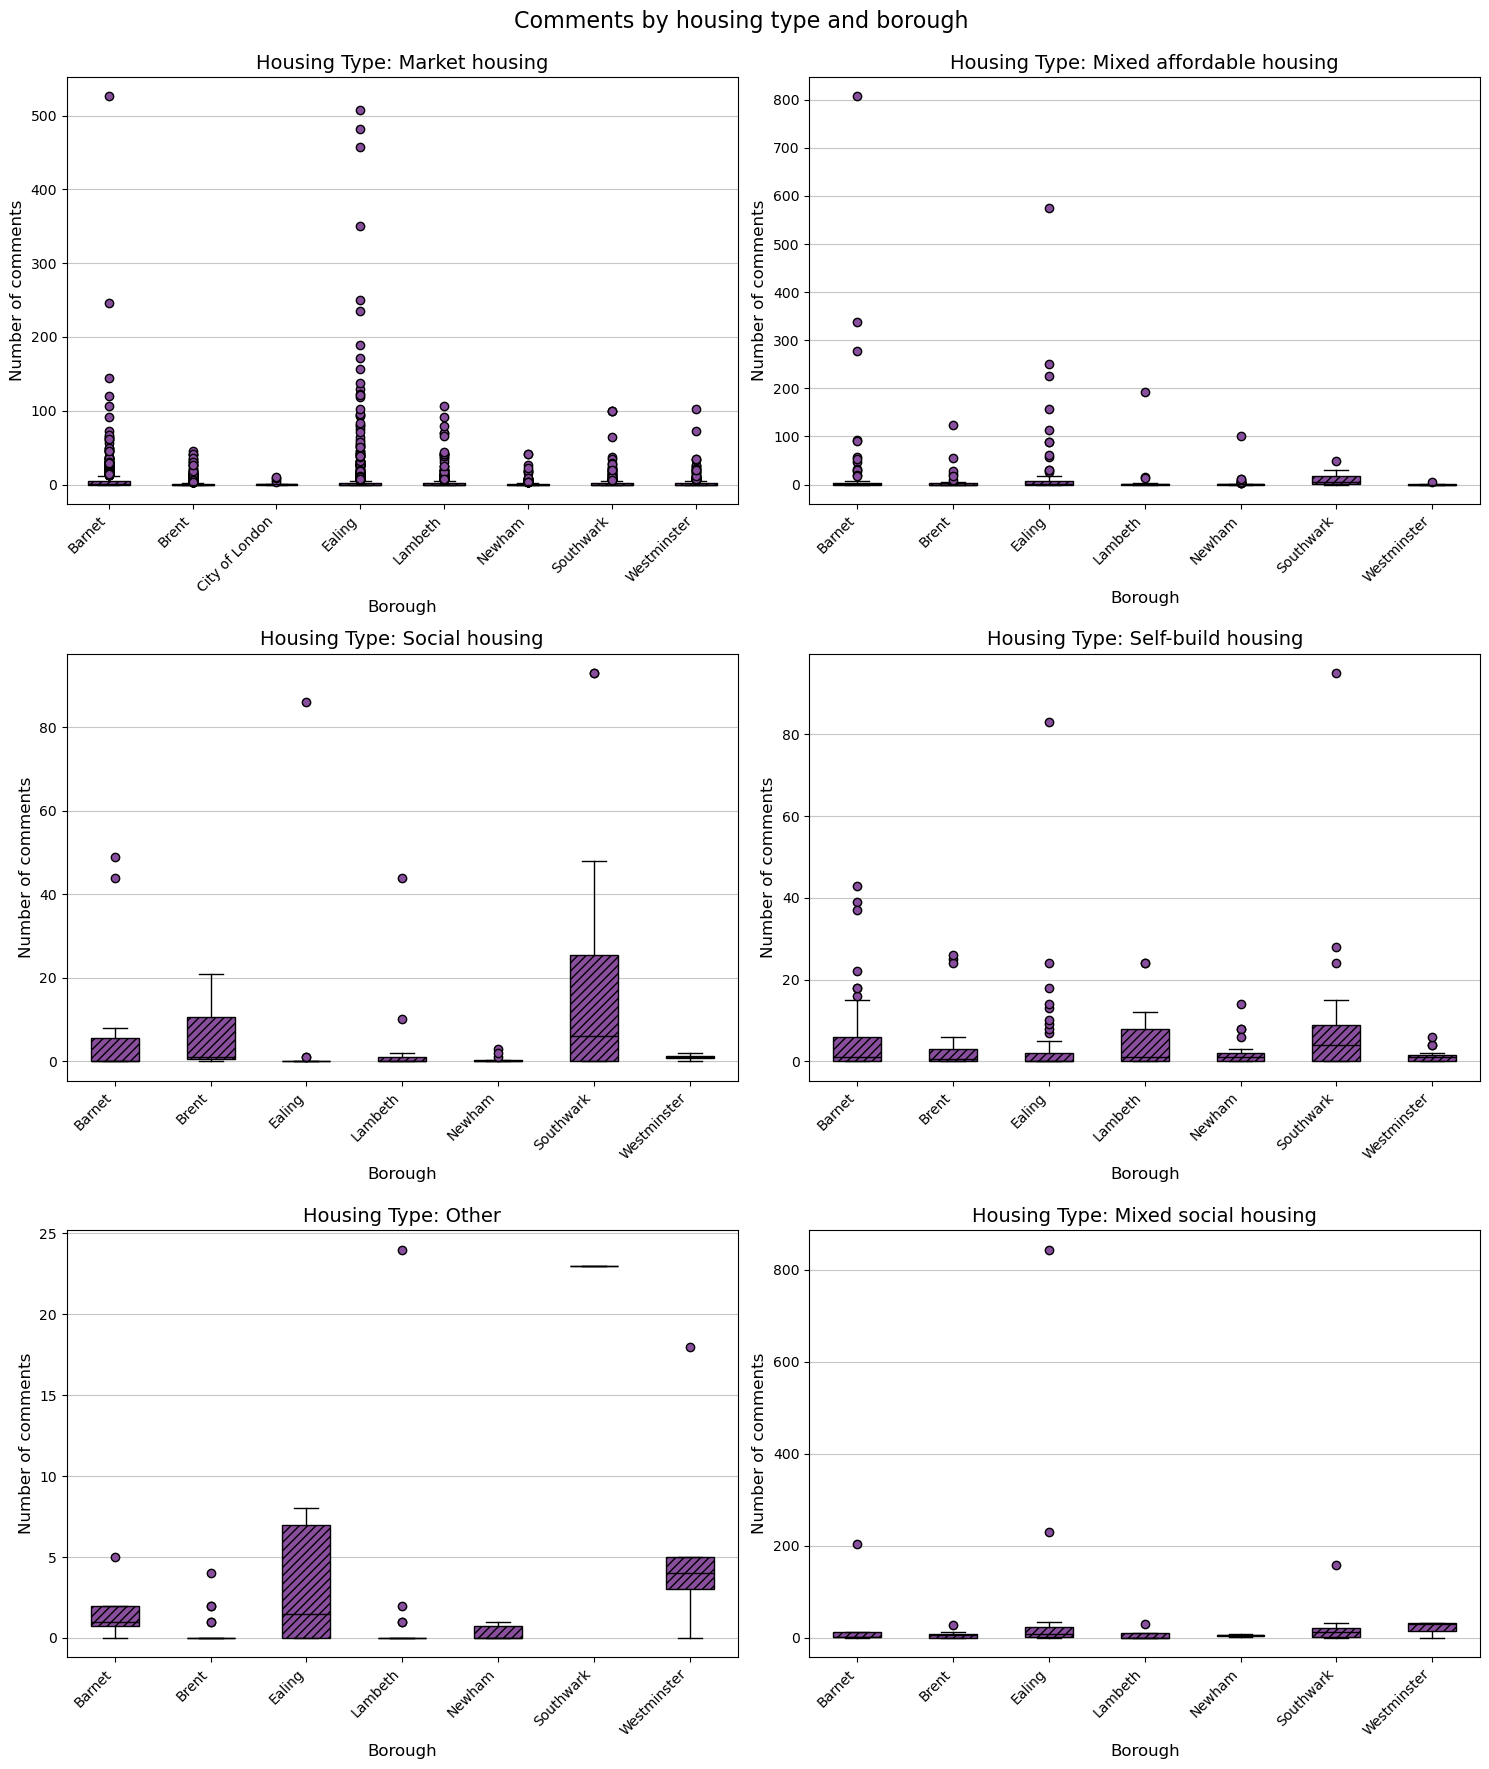

In [22]:
# plot grid of boxplots of comments per application by borough, by housing type
housing_types = application_df['housing_type'].dropna().unique()
n_types = len(housing_types)
n_cols = 2
n_rows = math.ceil(n_types / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 6), squeeze=False)
for i, housing_type in enumerate(housing_types):
    ax = axes[i // n_cols, i % n_cols]
    subset = application_df[application_df['housing_type'] == housing_type]
    color = "#894e9e"
    bp = subset.boxplot(
        column='comment_count',
        by='borough',
        grid=False,
        patch_artist=True,
        boxprops=dict(facecolor=color, color='black', hatch='////'),
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        flierprops=dict(markerfacecolor=color, markeredgecolor='black'),
        ax=ax,
        zorder=3
    )
    ax.set_title(f'Housing Type: {housing_type}', fontsize=14)
    ax.set_xlabel('Borough', fontsize=12)
    ax.set_ylabel('Number of comments', fontsize=12)
    ax.grid(axis='y', alpha=0.7, zorder=0)
    plt.sca(ax)
    plt.xticks(rotation=45, ha='right')

plt.suptitle('Comments by housing type and borough \n', fontsize=16) 
plt.tight_layout()
plt.savefig("../results/figures/boxplot_comments_per_application_borough_housing_type.png", dpi=500)
plt.show()

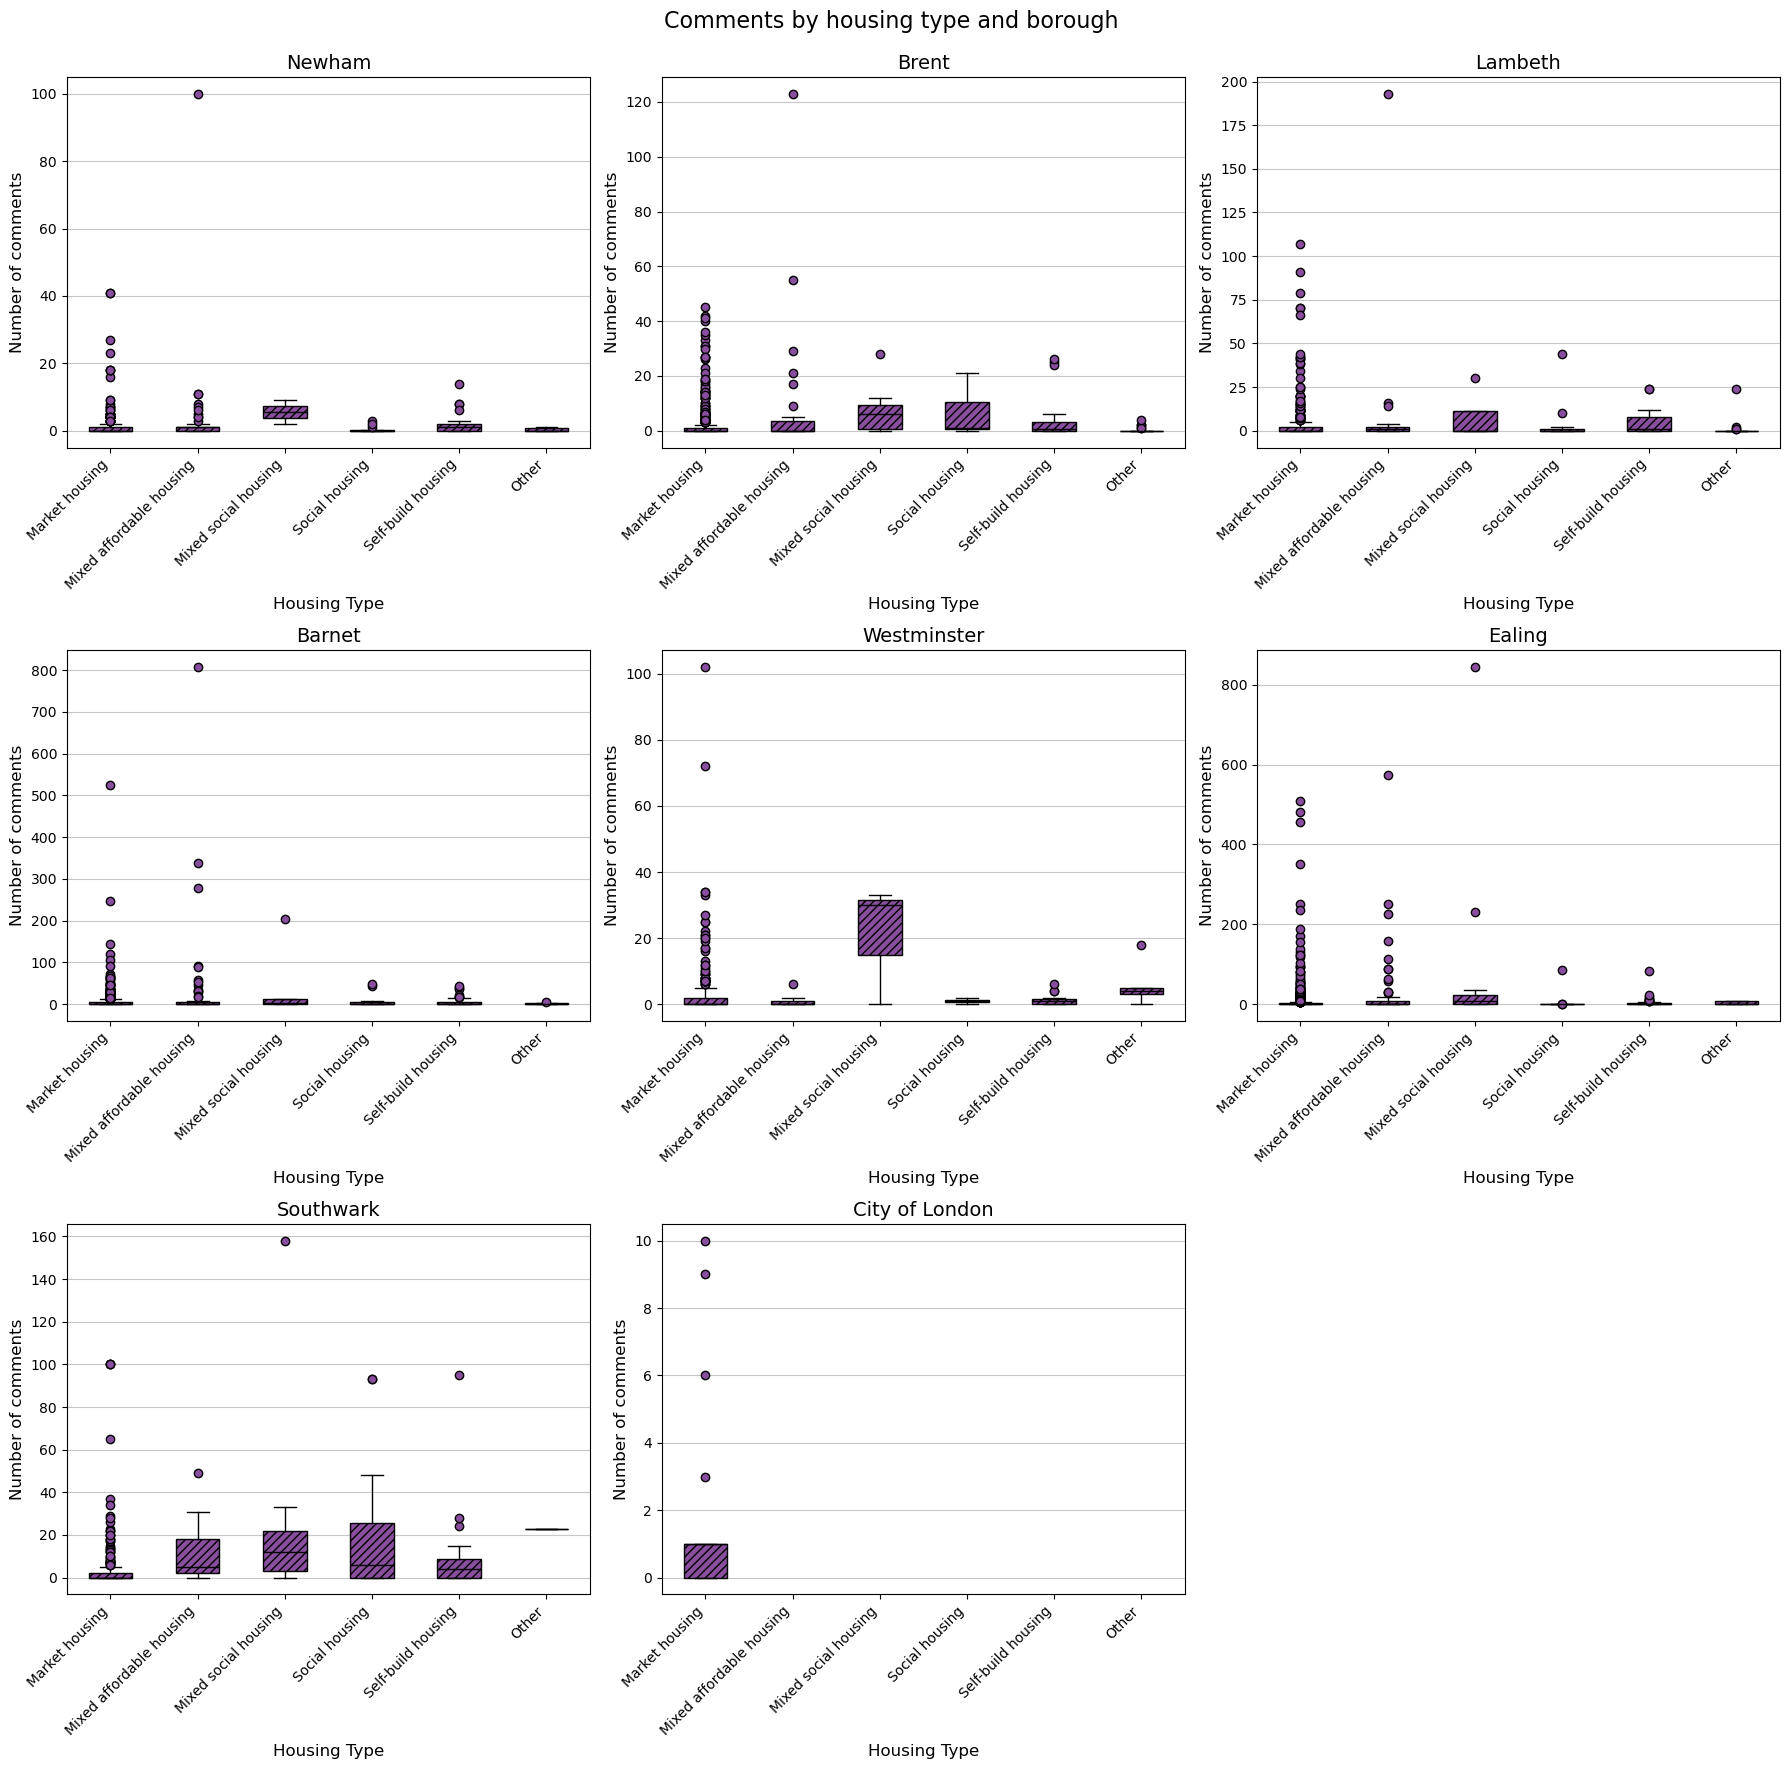

In [23]:
# Define desired order for housing types
housing_order = [
    'Market housing',
    'Mixed affordable housing',
    'Mixed social housing',
    'Social housing',
    'Self-build housing',
    'Other'
]

# Unique boroughs
boroughs = application_df['borough'].dropna().unique()
n_boroughs = len(boroughs)
n_cols = 3
n_rows = math.ceil(n_boroughs / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 6), squeeze=False)

for i, borough in enumerate(boroughs):
    ax = axes[i // n_cols, i % n_cols]
    subset = application_df[application_df['borough'] == borough]

    # Ensure housing_type is categorical with the specified order
    subset = subset.copy()
    subset['housing_type'] = pd.Categorical(subset['housing_type'], categories=housing_order, ordered=True)

    color = "#894e9e"
    bp = subset.boxplot(
        column='comment_count',
        by='housing_type',
        grid=False,
        patch_artist=True,
        boxprops=dict(facecolor=color, color='black', hatch='////'),
        medianprops=dict(color='black'),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        flierprops=dict(markerfacecolor=color, markeredgecolor='black'),
        ax=ax,
        zorder=3
    )

    ax.set_title(f'{borough}', fontsize=14)
    ax.set_xlabel('Housing Type', fontsize=12)
    ax.set_ylabel('Number of comments', fontsize=12)
    ax.grid(axis='y', alpha=0.7, zorder=0)
    plt.sca(ax)
    plt.xticks(rotation=45, ha='right')

# Remove any unused axes (e.g., if only 8 boroughs)
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols, j % n_cols])

plt.suptitle('Comments by housing type and borough \n', fontsize=16) 
plt.tight_layout()
plt.savefig("../results/figures/boxplot_comments_per_application_housing_type_borough.png", dpi=500)
plt.show()


### Scatter plot of number of residential units vs. number of comments 

In [24]:
# define colour palette
casa_purple = "#894e9e"
casa_green = "#abc766"
casa_pink = "#e16fca"
casa_yellow = "#f9dd73"
casa_blue = "#2e6260"
brown = "#a9746e"
grey = "#9f9f9fff"

# mapping from colours to housing types
housing_type_colors = {
    'Market housing': casa_purple,
    'Mixed affordable housing': casa_green,
    'Mixed social housing': casa_pink,
    'Social housing': casa_yellow,
    'Self-build housing': casa_blue,
    'Other': brown
}

In [29]:
len(application_df)

5235

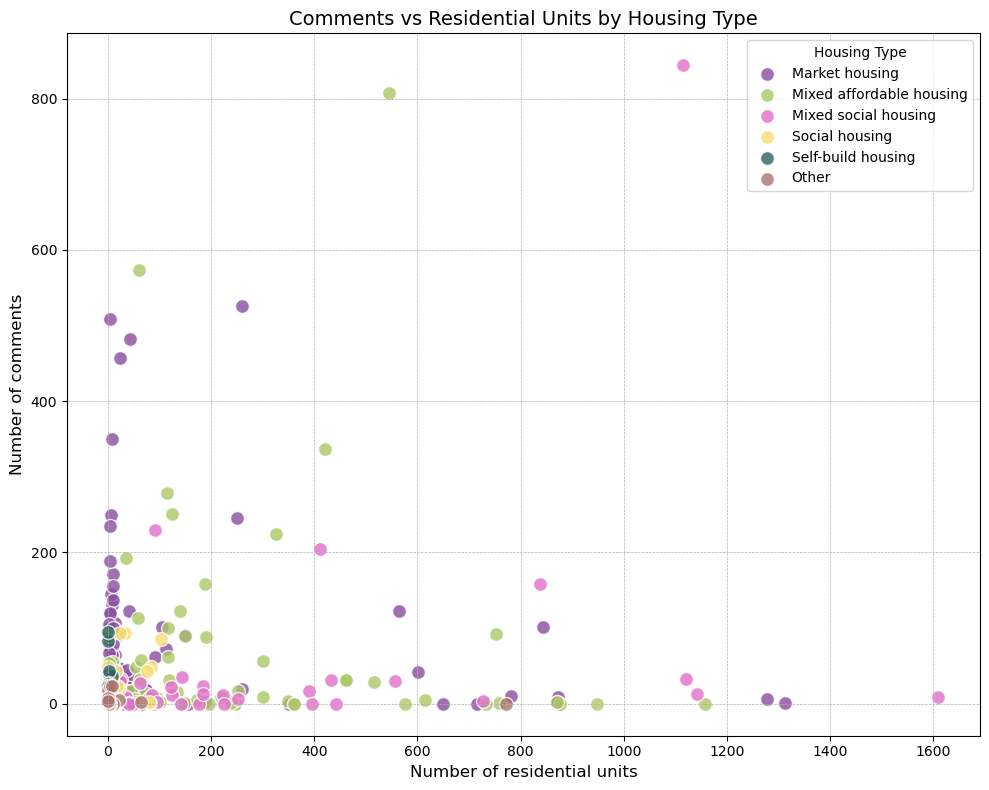

In [30]:
housing_order = [
    'Market housing',
    'Mixed affordable housing',
    'Mixed social housing',
    'Social housing',
    'Self-build housing',
    'Other'
]

plt.figure(figsize=(10,8))

# Loop through housing_order instead of unique()
# count the number of points plotted for each housing type to use as label in the legend
housing_type_counts = {}
for housing_type in housing_order:
    subset = application_df[application_df['housing_type'] == housing_type]
    if subset.empty:
        continue  # skip missing categories
    
    housing_type_counts[housing_type] = len(subset)
    plt.scatter(
        subset['total_no_proposed_residential_units'],
        subset['comment_count'],
        color=housing_type_colors.get(housing_type, 'grey'),
        label=housing_type,
        alpha=0.8,
        edgecolors='w',
        s=100
    )

plt.xlabel('Number of residential units', fontsize=12)
plt.ylabel('Number of comments', fontsize=12)
plt.title('Comments vs Residential Units by Housing Type', fontsize=14)

# Force legend order to match housing_order
handles, labels = plt.gca().get_legend_handles_labels()
ordered = [(h, l) for l, h in sorted(zip(labels, handles), key=lambda x: housing_order.index(x[0]) if x[0] in housing_order else len(housing_order))]
plt.legend([h for h, _ in ordered], [l for _, l in ordered], title='Housing Type')

plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.savefig("../results/figures/scatter_comments_vs_residential_units.png", dpi=500)
plt.show()


In [31]:
housing_type_counts

{'Market housing': 4365,
 'Mixed affordable housing': 246,
 'Mixed social housing': 48,
 'Social housing': 89,
 'Self-build housing': 288,
 'Other': 75}

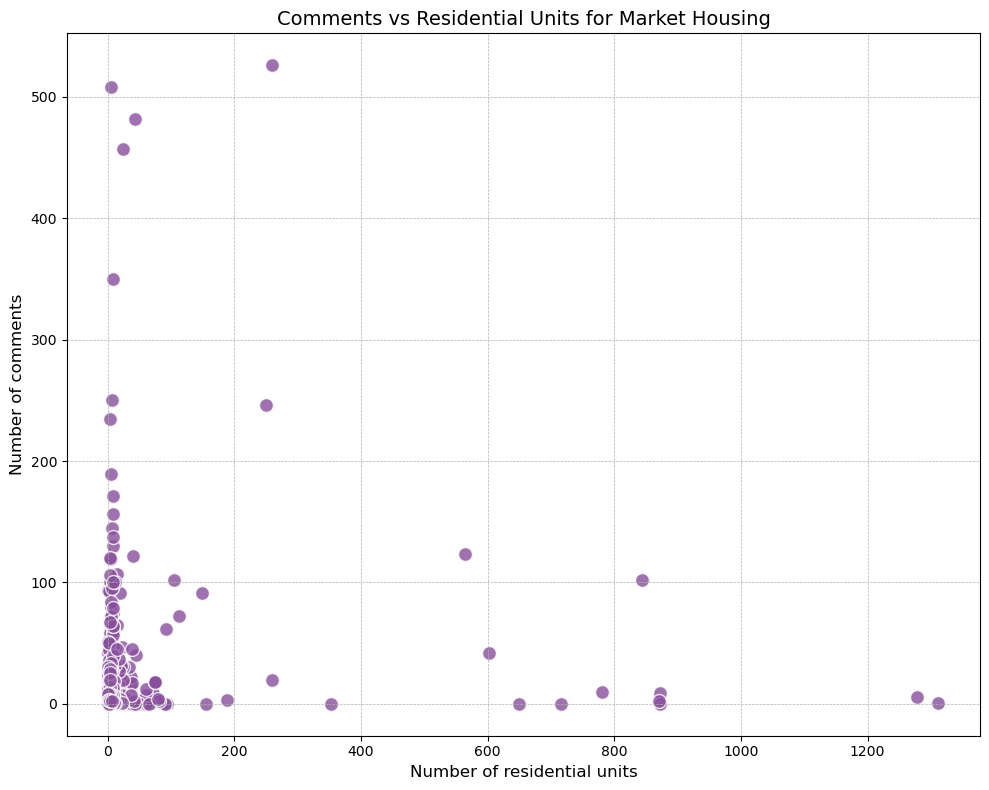

In [32]:
# just plot the scatter for market housing 

subset = application_df[application_df['housing_type'] == 'Market housing']
plt.figure(figsize=(10,8))
plt.scatter(
    subset['total_no_proposed_residential_units'],
    subset['comment_count'],
    color=housing_type_colors.get('Market housing', 'grey'),
    label='Market housing',
    alpha=0.8,
    edgecolors='w',
    s=100
)
plt.xlabel('Number of residential units', fontsize=12)
plt.ylabel('Number of comments', fontsize=12)
plt.title('Comments vs Residential Units for Market Housing', fontsize=14)
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()

In [39]:
print(len(application_df[application_df['housing_type'] == "Other"]))

conversion = {'change of use', 'conversion'}

# regex to check if 'change of use' or 'conversion' is in the description of the application for hosuing_type='Other' 
application_df[application_df['housing_type'] == 'Other']['description'].str.contains('change of use|conversion|extension', case=False, na=False).sum()

75


40

In [42]:
# display those which are 'housing_type' == 'Other' and do not have 'change of use' or 'conversion' in the description
other_without_conversion = application_df[
    (application_df['housing_type'] == 'Other') & 
    (~application_df['description'].str.contains('change of use|conversion|extension', case=False, na=False))
]
other_without_conversion

,lpa_app_no,valid_date,decision_date,borough,total_no_proposed_residential_units,total_no_affordable_units,site_area,habitable_rooms_density,pp_id,uprn,...,decision,street_name,site_name,site_number,polygon,wgs84_polygon,description,housing_type,comment_count,outcome
327,22/01556/FUL,NaT,NaT,Lambeth,2,NaN,297.00000,0.0,PP-11227231,1.000234e+11,...,Allowed,NaN,32 Lansdowne Gardens\nLondon\nLambeth\nSW8 2EG,NaN,GEOMETRYCOLLECTION (POLYGON ((530198.35 176912...,"polygon=linearring(x=[-0.12661029999999998, -0...","Re-configuration to create two dwellings, and ...",Other,2,Permitted
346,22/02680/NMC,NaT,NaT,Lambeth,3,NaN,330000.00000,0.0,PP-11411953,1.000879e+10,...,Approved,Development Control Pseudo Street,Streatham Place Including Clapham Park Estate ...,NaN,NaN,"polygon=linearring(x=[-0.13345179999999998, -0...",Application for a non-material amendment follo...,Other,0,Permitted
410,22/3321,NaT,NaT,Brent,1,NaN,0.02000,0.0,PP-11572027,2.020622e+08,...,Approved,NaN,"644 North Circular Road, Neasden, London, NW2 7QJ",NaN,"polygon=linearring(x=[521284.354, 521284.36, 5...","polygon=linearring(x=[-0.251454, -0.251455, -0...",Certificate of lawfulness for existing use as ...,Other,0,Permitted
476,22/06901/FULL,NaT,NaT,Westminster,1,NaN,NaN,NaN,PP-11549560,1.003361e+10,...,Approved,NaN,1-15 Portsea Mews And 8 Porchester Place,NaN,NaN,NaN,NaN,Other,18,Permitted
477,22/2225,NaT,NaT,Brent,2,NaN,0.13000,0.0,PP-11223341,2.020136e+08,...,Approved,NaN,"Fairgate House, 390-400 and 402-408 (Even), Hi...",NaN,"polygon=linearring(x=[518604.65, 518603.75, 51...",NaN,Demolition of existing buildings and construct...,Other,2,Permitted
550,23/03751/LDCE,NaT,NaT,Lambeth,2,NaN,NaN,NaN,PP-12622550,1.000219e+11,...,Approved,Hubert Grove,NaN,79,GEOMETRYCOLLECTION (POLYGON ((530502.74 175600...,"polygon=linearring(x=[-0.1227134, -0.122738199...",Application for a Certificate of Lawful Develo...,Other,0,Permitted
711,22/02604/FUL,NaT,NaT,Lambeth,4,NaN,557.81000,0.0,PP-11370678,2.000005e+11,...,Approved,NaN,Plot Between Lynwood And Macaulay Court \nMaca...,NaN,GEOMETRYCOLLECTION (POLYGON ((528902.457 17568...,"polygon=linearring(x=[-0.14570719999999998, -0...",Removal of existing swimming pool and erection...,Other,24,Permitted
885,23/02697/LDCE,NaT,NaT,Lambeth,4,NaN,NaN,NaN,PP-12396611,1.000233e+11,...,Approved,Gleneldon Road,NaN,8,GEOMETRYCOLLECTION (POLYGON ((530101.25 171635...,"polygon=linearring(x=[-0.1299459, -0.130076, -...",Application for a Certificate of Lawful Develo...,Other,0,Permitted
1035,23/0414,NaT,NaT,Brent,1,NaN,0.03478,0.0,PP-11916588,2.020751e+08,...,Approved,NaN,"125 Leighton Gardens, London, NW10 3PS",NaN,NaN,"polygon=linearring(x=[-0.228617, -0.228618, -0...",Demolition of existing dwellinghouse and rear ...,Other,0,Permitted
1078,23/00335/FUL,NaT,NaT,Newham,1,NaN,NaN,NaN,PP-11928524,4.603218e+07,...,Approved,NaN,486 Green Street,NaN,NaN,NaN,NaN,Other,1,Permitted
